# Projekt 2 - Krzywe sklejane

# Opis projektu

Celem projektu jest implementacja krzywych B-sklejanych, za pomocą których mamy utworzyć kształt litery 'P'. 

Wykorzystuję do tego w sporym stopniu kod z laboratorium nr. 7, ale wprowadzam też kilka modyfikacji.

## Problemy
Największym problemem jest to, że krzywa b-sklejana zawsze zaczyna się i kończy w punkcie (0,0). Aby to obejść za każdym razem gdy tworzę krzywą, tworzę kopię pierwszego i ostatniego punktu kontrolnego odpowiednią ilość razy w zależności od stopnia krzywej. 

Dodajemy także marginesy listy węzłów, które poszerzają obszar wyznaczania węzłów z obu stron (dodając ujemny i dodatni margines wynikający ze stopnia powielenia punktów).

Aby sprawić by krzywa nie wracała do początku układu po prostu nie rysuje ostatniego łuku (od ostatniego punktu kontrolnego do punktu (0,0)). Jako że dodałem kopie ostatniego i pierwszego punktu to odcięcie tych łuków nie wpływa na kształt krzywej.

W ten sposób ostatni łuk krzywej kończy się w ostatnim punkcie kontrolnym, a łuk, którego nie rysuje zaczyna się w KOPII ostatniego punktu i kończy w pierwszym punkcie (0,0). W ten sposób ostatni łuk, który faktycznie rysuje (przedostatni) nie jest wykrzywiony przez punkt początkowy.




# Funkcja `bspline0` podana na laboratorich nr. 7

In [25]:
import numpy as np
import matplotlib.pyplot as plt


def bspline0(T, t, M):
    """Dyskretna reprezentacja bazowych funkcji B-sklejanych stopnia 0.

    Parametry
    ---------
    T : array-like
        Wektor węzłów o M + 1 wartościach, w tym 0 i 1.
    t : array-like
        Punkty próbkowania z przedziału [0, 1].
    M : int
        Liczba bazowych funkcji stopnia 0.

    Zwraca
    -------
    numpy.ndarray
        Tablica o kształcie (len(t), M) z próbkowanymi funkcjami bazowymi.
    """
    T = np.asarray(T)
    t = np.asarray(t)

    poly0 = np.zeros((t.size, M), dtype=int)
    for j in range(M):
        poly0[:, j] = ((t >= T[j]) & (t < T[j + 1])).astype(int)
    return poly0

# Zadanie 1 - testy funkcji bspline0


Text(0.5, 1.0, 'Funkcje bazowe B-sklejane stopnia 0')

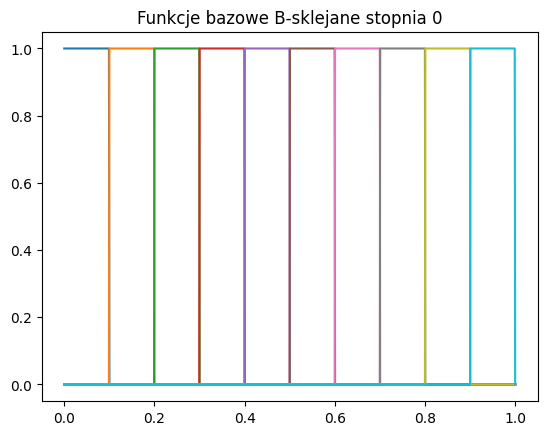

In [26]:
M = 10
# możemy użyć np.arrange zamiast np.linspace
# t = np.arange(0, 1, 0.001)
t = np.linspace(0, 1, 1000)
T = np.linspace(0, 1, M + 1)


poly1 = bspline0(T, t, M)
plt.plot(t, poly1)
plt.title("Funkcje bazowe B-sklejane stopnia 0")

# Rekurencyjna definicja funkcji `bspline`
Wykorzystujemy funckję `bspline0` podanej na laboratoriach do stworzenia uniwersalnej, rekurencyjnej funkcji `bspline`, która pozwoli nam tworzyć krzywe sklejane dowolnego stopnia. 

W ten sposób oszczędzimy linijek kodu i uprościmy logikę programu.

Text(0.5, 1.0, 'Wielomiany B-sklejane stopnia 6')

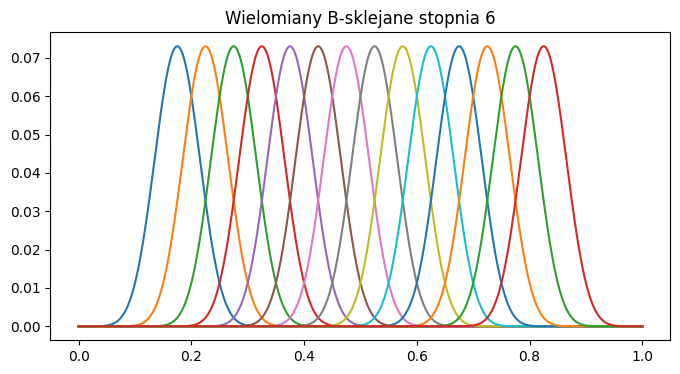

In [27]:
def bspline(T, t, M, degree):
    """
    Rekurencyjna funkcja obliczająca bazowe wielomiany B-sklejane dowolnego stopnia.
    """

    # implementacja funckji bspline0 z laboratoriów
    if degree == 0:
        T = np.asarray(T)
        t = np.asarray(t)
        poly0 = np.zeros((t.size, M), dtype=int)
        for j in range(M):
            poly0[:, j] = ((t >= T[j]) & (t < T[j + 1])).astype(int)
        return poly0

    poly_prev = bspline(T, t, M, degree - 1)
    poly_curr = np.zeros((t.size, M - degree))

    for j in range(M - degree):
        mianownik = T[j + degree + 1] - T[j]
        if mianownik != 0:
            poly_curr[:, j] = (
                (t - T[j]) * poly_prev[:, j]
                + (T[j + degree + 1] - t) * poly_prev[:, j + 1]
            ) / mianownik
        else:
            poly_curr[:, j] = 0

    return poly_curr


M = 20
t = np.linspace(0, 1, 1000)
T = np.linspace(0, 1, M + 1)
poly = bspline(T, t, M, 6)
plt.figure(figsize=(8, 4))
plt.plot(t, poly)
plt.title("Wielomiany B-sklejane stopnia 6")

# Wygenerowana funkcja do tworzenia Spline'a

Funkcja do generowania krzywej B-sklejanej przyjmuje jako argumenty tylko listę punktów kontrolnych i stopień krzywej. Wewnątrz funkcji generujemy odpowiednie parametry dla funkcji bspline w zależności od liczby punktów kontrolnych i stopnia krzywej.

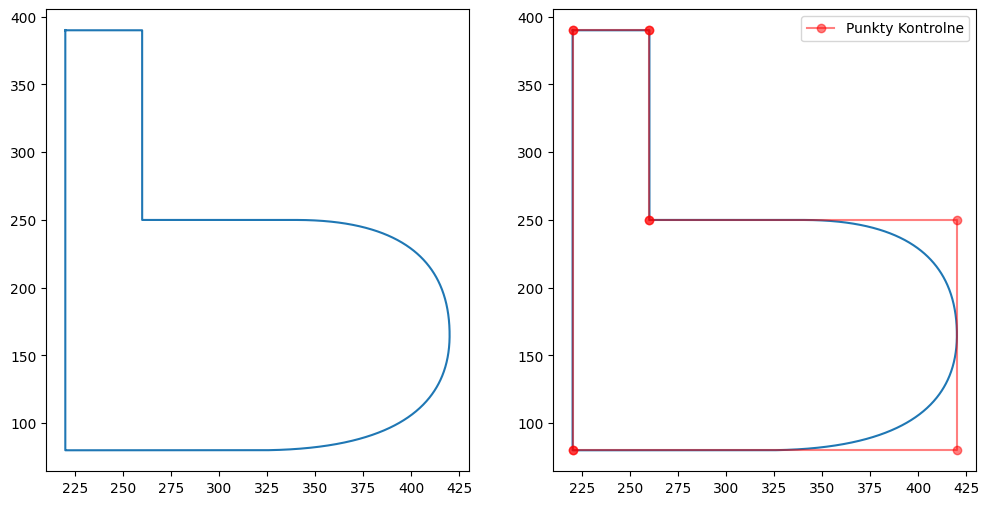

In [28]:
def create_spline(points, degree=2):

    points = np.asarray(points)

    # Aby krzywa nie wracała do (0,0), zapobiegamy temu "klonując" pierwszy i ostatni
    # punkt tyle razy, ile wynosi stopień krzywej.
    # Krzywa zostanie przez to wykrzywiona tak mocno, że musi ona przejść (zacząć się) w pierwszym
    # wierzchołku i zakończyć się w ostatnim.
    padded_points = np.vstack(
        [np.tile(points[0], (degree, 1)), points, np.tile(points[-1], (degree, 1))]
    )

    num_points = padded_points.shape[0]

    M = num_points + degree

    # MARGINES LISTY WĘZŁÓW
    # Poszerzając wektor T, sprawiamy ze obszar obliczeń parametrów (t od 0 do 1)
    # omija te miejsca na skrajach matematycznych krzywej, przed jej starem i końcem, gdzie
    # wagi funkcji zanikają i ściągają nas gwałtownie do (0,0).
    margin = degree / M
    T = np.linspace(-margin, 1 + margin, M + 1)
    t = np.linspace(0, 1, 6000)

    poly = bspline(T, t, M, degree)

    # Ponieważ korzystamy z poszerzonej listy węzłów,
    # suma funkcji bazowych na skrajach czasu t nie wynosi idealnie 1.
    # Musimy znormalizować współczynniki, inaczej krzywa będzie niepoprawna.
    poly_weights = poly[:, :num_points]
    poly_sum = np.sum(poly_weights, axis=1, keepdims=True)
    poly_sum[poly_sum == 0] = 1

    # Wektorowe (macierzowe) nałożenie poprawionych wag na nasze punkty:
    spline_pts = (poly_weights / poly_sum) @ padded_points

    return spline_pts


pts = np.array(
    [
        [220, 390],
        [220, 80],
        [220, 80],
        [420, 80],
        [420, 250],
        [260, 250],
        [260, 250],
        [260, 390],
        [260, 390],
        [220, 390],
    ]
)
spline = create_spline(pts, degree=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].plot(spline[:, 0], spline[:, 1])
# plt.figure(figsize=(7, 7))
axes[1].plot(spline[:, 0], spline[:, 1])
axes[1].plot(pts[:, 0], pts[:, 1], "ro-", label="Punkty Kontrolne", alpha=0.5)
axes[1].legend()
plt.show()

# Omówienie wyników 
Jak możemy zauważyć, kształt jest poprawnie generowany na podstawie punktów kontrolnych. Kąty ostre są sztucznie osiągnięte za pomocą ręcznego skopiowania niektórych punktów kontrolnych. Tam gdzie punkty sa pojedyncze, krzywe jest zaokrąglona. Nie widać początku i powrotu przywej do punktu (0,0).

# Wypełnianie Kształtu Spline

Aby przenieść wygenerowaną krzywą na obraz, tworzymy nową funkcję. 
Funkcja ta przyjmuje punkty krzywej, konwertuje je na wartości całkowite (piksele) i rysuje ją na macierzy obrazu.

Aby uprościć kod stosuję funkcję biblioteki openCV `cv2.polylines`, która pozwala na narysowanie krzywej jako ciąg połączonych linii prostych. Funkcja ta **odpowiada jedynie za narysowanie konturu**, wyliczenia punktów są wykonawane przez funkcję z poprzedniej komórki.

Dodatkowo funkcja pozwala na wypełnienie zamkniętego kształtu wybranym kolorem. Wykorzystujemy do tego algorytm `cv2.floodFill`, któremu podajemy punkt startowy

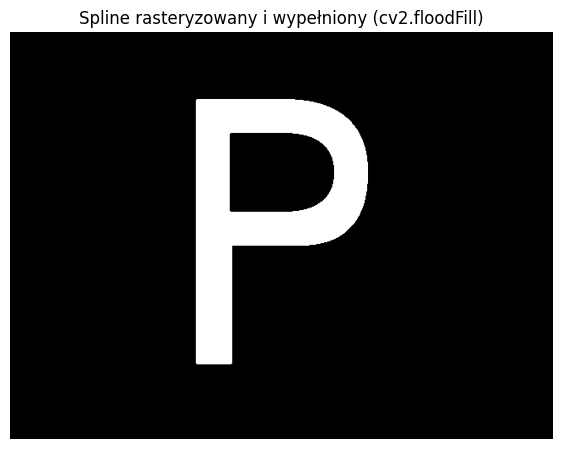

In [29]:
import cv2


def render_spline_to_image(
    spline_pts,
    img=None,
    line_color=(255, 255, 255),
    thickness=2,
    fill=False,
    fill_start_point=None,
    fill_color=(100, 100, 100),
):
    if img is None:
        raise ValueError("brak obrazu")

    # konwertujemy punkty krzywej do liczb całkowitych (pikseli)
    pts = np.int32(np.round(spline_pts))
    pts = pts.reshape((-1, 1, 2))

    # Rysujemy wygładzoną krzywą B-spline za pomocą ułożenia odcinków
    cv2.polylines(img, [pts], isClosed=False, color=line_color, thickness=thickness)

    if fill and fill_start_point is not None:
        # cv2.floodFill wymaga maski o rozmiarze +2 piksele w każdym wymiarze
        mask = np.zeros((img.shape[0] + 2, img.shape[1] + 2), np.uint8)
        cv2.floodFill(img, mask, fill_start_point, fill_color)

    return img


img = np.zeros((480, 640, 3), dtype=np.uint8)

# DEFINICJA PUNKTÓW LITERY P
pts = np.array(
    [
        [220, 390],
        [220, 80],
        [220, 80],
        [420, 80],
        [420, 250],
        [260, 250],
        [260, 250],
        [260, 390],
        [260, 390],
        [220, 390],
    ]
)

spline = create_spline(pts, degree=2)

img_cv2 = render_spline_to_image(
    spline,
    img=img,
    line_color=(255, 255, 255),
    thickness=2,
    fill=True,
    fill_start_point=(
        270,
        200,
    ),
    fill_color=(255, 255, 255),
)


# DEFINICJA PUNKTÓW DZIURY W LITERZE P
hole_points = np.array(
    [[260, 120], [380, 120], [380, 210], [260, 210], [260, 210], [260, 120]]
)
hole_spline = create_spline(hole_points, degree=2)

img_cv2 = render_spline_to_image(
    hole_spline,
    img=img_cv2,
    line_color=(0, 0, 0),
    thickness=2,
    fill=True,
    fill_start_point=(320, 150),  # Punkt wewnątrz dziury 'P'
    fill_color=(0, 0, 0),
)


plt.figure(figsize=(7, 7))
plt.imshow(img_cv2)
plt.title("Spline rasteryzowany i wypełniony (cv2.floodFill)")
plt.axis("off")
plt.show()

# Omówienie wyników

Funkcja poprawnie wytworzyła obraz litery P, a drugie wywołanie tej funkcji stworzyło w niej 'dziurę' poprzez wypełnienie drugiej krzywej czarnym kolorem.
Otrzymaliśmy poprawny obraz.

# Zadanie 2 - generowanie animacji

Funkcja `create_spline_animation` wykorzystuje wcześniej zdefniowane funkcję do wytworzenia obrazu. Pozwala ona na ustalenie parametrów animacji i wykona serię obrazów na wzór tych z poprzedniego zadania. Wszystkie obrazy zostaną zapisane jako wideo.

Istotną różnicą jest przekazanie parametrów points_start i points_end oraz hole_start i hole_end. Na potrzeby tego konkretnego zadania pozwalają one na zmianę współrzędnych punktów kontrolnych. 
Co za tym idzie, funkcja ta nie jest uniwersalna, ale pozwala na wykonanie tego konkretnego zadania.

Aby urozmaicić animacje, dodaję tło w postaci obrazka. 
Każda klatka to kopia tła, w której nadpisuje pixele wygenerowane przez funkcję `render_spline_to_image`.
Aby móc używać algorytmu floodfill tworzę krzywą na osobnym obrazku i maskuję ją na tle.


In [30]:
def create_spline_animation(
    points_start,
    points_end,
    hole_start,
    hole_end,
    filename="spline_anim.avi",
    frames=250,
    fps=25,
    degree=2,
    loops=1,
):
    pts_start = np.asarray(points_start, dtype=float)
    pts_end = np.asarray(points_end, dtype=float)

    h_start = np.asarray(hole_start, dtype=float)
    h_end = np.asarray(hole_end, dtype=float)

    # Używamy tej samej rozdzielczości obrazu
    width, height = 640, 480

    fourcc = cv2.VideoWriter_fourcc(*"XVID")
    video_writer = cv2.VideoWriter(filename, fourcc, fps, (width, height))
    bg_img = cv2.imread("windows.jpg")

    if not video_writer.isOpened():
        print(
            f"Błąd inicjalizacji zapisu wideo dla pliku {filename}. Prawdopodobnie brakuje systemowego kodeka lub ścieżka jest zablokowana."
        )
        return

    frames_per_loop = max(1, frames // loops)

    for loop_idx in range(loops):
        current_loop_frames = frames_per_loop
        if loop_idx == loops - 1:
            current_loop_frames = frames - (loop_idx * frames_per_loop)

        for i in range(current_loop_frames):
            t = i / max(1, (current_loop_frames - 1))

            # Logika odpowiadająca za odtworzenie animacji od tyłu w co drugiej pętli.
            if loop_idx % 2 == 1:
                t = 1.0 - t

            # Interpolacja obrysu
            current_points = (1 - t) * pts_start + t * pts_end
            # Interpolacja dziury
            current_hole = (1 - t) * h_start + t * h_end

            # Wyliczenie krzywych
            spline_pts = create_spline(current_points, degree=degree)
            spline_hole = create_spline(current_hole, degree=degree)

            img = np.zeros((height, width, 3), dtype=np.uint8)

            # Rysujemy główny kształt P - i napełniamy go kolorem
            img = render_spline_to_image(
                spline_pts,
                img=img,
                line_color=(0, 255, 0),
                thickness=1,
                fill=True,
                fill_start_point=(270, 200),
                fill_color=(0, 255, 0),
            )

            # Na tym samym obrazie rysujemy dziurę
            img = render_spline_to_image(
                spline_hole,
                img=img,
                line_color=(0, 0, 0),
                thickness=1,
                fill=True,
                fill_start_point=(263, 165),
                fill_color=(0, 0, 0),
            )

            final_img = bg_img.copy()

            # Szukamy pikseli, które nie są czarne (gdzieś mają wartość > 0)
            mask = np.any(img != 0, axis=-1)
            # Nadpisujemy tło wygenerowanymi pikselami
            final_img[mask] = img[mask]

            video_writer.write(final_img)

    video_writer.release()


P_points_start = np.array(
    [
        [220, 390],
        [220, 80],
        [220, 80],
        [420, 80],
        [420, 250],
        [260, 250],
        [260, 250],
        [260, 390],
        [260, 390],
        [220, 390],
    ]
)

hole_points_start = np.array(
    [[260, 120], [380, 120], [380, 165], [380, 210], [260, 210], [260, 210], [260, 120]]
)
hole_points_end = np.array(
    [[260, 120], [260, 165], [380, 165], [260, 165], [260, 210], [260, 210], [260, 120]]
)


create_spline_animation(
    points_start=P_points_start,
    points_end=P_points_start,
    hole_start=hole_points_start,
    hole_end=hole_points_end,
    filename="animacja_litery_P.avi",
    frames=200,
    fps=30,
    degree=2,
    loops=3,
)

# Omówienie wyniku.

Funkcja poprawnie wygenerowała serię obrazów i połączyła je w animację wideo. Wygenerowany obraz jest poprawnie nałożony na tło.